# Logistic Regression

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Importing the dataset
dataset = pd.read_csv(r"C:\Users\Windows10 Pro\Downloads\DataScience_AI\Assignments_JupyterFile\10. Machine_Learning\Regression_Model\8. Logistic_Regresison\Social_Network_Ads.csv")

In [3]:
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, -1].values

In [4]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
#for this observation let me selcted as 100 observaion for test set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [5]:
#we are going to predict which users are going to predit xuv, 

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler() 
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test) 

In [6]:
#Next step is we are going to build the logistic model and appy this model into our dataset 
#This is linear model library thats why we called from sklear.linear_model

# Training the Logistic Regression model on the Training set

from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(penalty="l2",solver="liblinear")
classifier.fit(X_train, y_train)
#we have to fit the logistic regression model to our training set

LogisticRegression(solver='liblinear')

In [7]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)
#now you compare X_test with y_pred, x-test we ha,ve age and salary , 
#if u look at the first observation this user is not be able to buy the car but if you look at observation 7 then that user is going to buy the car
#in this case logistic regression model classify the which users are going to buy the car or not 

In [8]:
#we build our logistic model and fit it to the training set & we predict our test set result 

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[56,  2],
       [ 5, 17]], dtype=int64)

In [9]:
from sklearn.metrics import accuracy_score
ac = accuracy_score(y_test, y_pred)
ac

0.9125

In [10]:
# This is to get the Classification Report
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
cr

'              precision    recall  f1-score   support\n\n           0       0.92      0.97      0.94        58\n           1       0.89      0.77      0.83        22\n\n    accuracy                           0.91        80\n   macro avg       0.91      0.87      0.89        80\nweighted avg       0.91      0.91      0.91        80\n'

In [11]:
bias = classifier.score(X_train,y_train)
bias

0.81875

In [12]:
variance = classifier.score(X_test, y_test)
variance

0.9125

In [15]:
#-----------------FUTURE PREDICTION ------------
dataset1 = pd.read_csv(r"C:\Users\Windows10 Pro\Downloads\DataScience_AI\Assignments_JupyterFile\10. Machine_Learning\Regression_Model\8. Logistic_Regresison\Social_Network_Ads.csv")

d2 = dataset1.copy()

dataset1 = dataset1.iloc[:, [2, 3]].values

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
M = sc.fit_transform(dataset1)

In [17]:
y_pred1 = pd.DataFrame()

In [18]:
d2 ['y_pred1'] = classifier.predict(M)

d2.to_csv('final1.csv')

In [19]:
'''
# To get the path 
import os
os.getcwd()
'''

'\n# To get the path \nimport os\nos.getcwd()\n'

C:\Users\Windows10 Pro\AppData\Local\Temp\ipykernel_5776\821767583.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


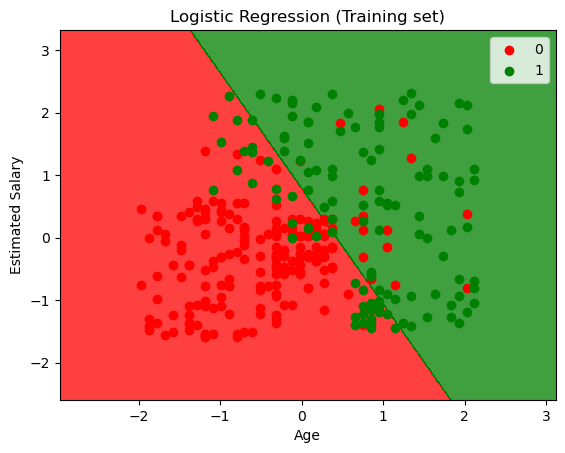

In [20]:
#Now we gonna see the visulization 

# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

C:\Users\Windows10 Pro\AppData\Local\Temp\ipykernel_5776\2294049621.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


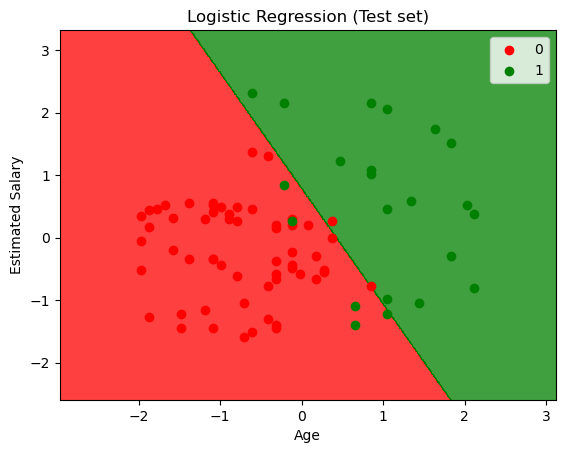

In [21]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [22]:
#lets see the graph we get good graph we have plotted for the test data point 
#if you see the confustion matrix we saw 11 points are incorrectly predicted hear , you can count that 
#we build our first classification model in python 